# Data processing

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sm

In [25]:
# data set entrainement
path = r"/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"

x_train = pd.read_csv(path + r"/X_train_NHkHMNU.csv").sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(path + r"/y_train_ZAN5mwg.csv")

# ensemble de test
x_test = pd.read_csv(path + r"/X_test_final.csv")
y_test = pd.read_csv(path + r"/y_test_random_final.csv")

## Visualisation

In [26]:
display(x_train.head(5))
display(y_train.head(5))

,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,...,FR_RESIDUAL_LOAD,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
1468,111,2,DE,-0.068972,-0.667390,-1.102015,1.102015,-1.080403,0.256736,1.080403,...,-0.540642,-0.344600,-0.372156,-0.623041,-0.926064,-0.148950,0.641235,1.802550,1.140920,0.900434
680,800,3,DE,-0.134670,-0.834564,-1.051716,1.051716,-1.881881,-0.612133,1.881881,...,-0.856321,-1.394561,-1.118297,0.244859,0.488650,-1.710888,-0.951057,0.440121,-0.064550,-0.032756
991,831,5,DE,-0.297850,-0.470371,0.144615,-0.144615,-1.208286,-1.811403,1.208286,...,-0.552878,-1.374757,-0.790071,0.333817,0.021868,-0.062187,1.459745,-0.117977,0.550433,0.781870
1356,779,7,DE,0.057599,-0.625625,0.002239,-0.002239,-0.676226,-0.745182,0.676226,...,-0.806379,-0.531862,-0.663419,0.098940,1.367421,-0.812164,0.954384,-0.379980,0.518459,-0.034642
713,841,8,DE,-0.282744,-0.700027,1.309253,-1.309253,0.248085,-2.226840,-0.248085,...,-0.791016,1.522720,-0.307449,1.690497,1.584210,-0.441943,-0.382423,1.557325,0.146634,2.329924


,ID,TARGET
0,1054,0.028313
1,2049,-0.112516
2,1924,-0.180840
3,297,-0.260356
4,1101,-0.071733


## Types / Shape

In [27]:
display(x_train.dtypes)
display(x_train.shape)

ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

(1494, 35)

## Statistiques descriptives

In [28]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


## Target

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

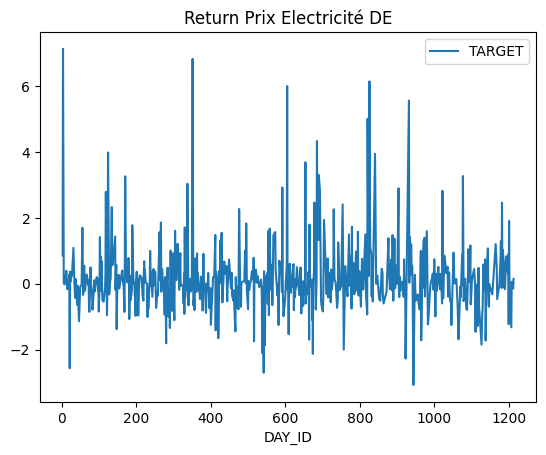

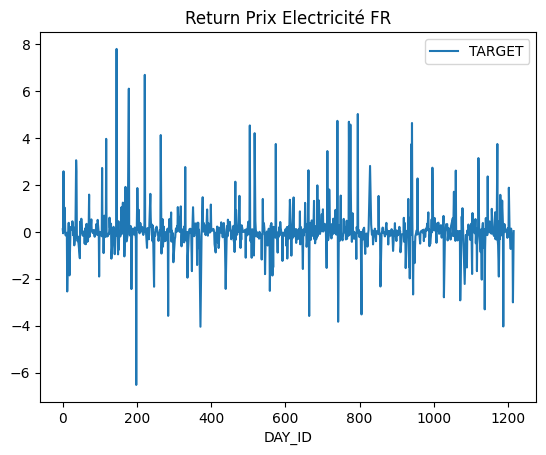

In [29]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

## Gestion des valeurs manquantes

In [19]:
x_train.isna().sum()

ID                    0
DAY_ID                0
COUNTRY               0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
DE_NET_EXPORT       124
FR_NET_EXPORT        70
DE_NET_IMPORT       124
FR_NET_IMPORT        70
DE_GAS                0
FR_GAS                0
DE_COAL               0
FR_COAL               0
DE_HYDRO              0
FR_HYDRO              0
DE_NUCLEAR            0
FR_NUCLEAR            0
DE_SOLAR              0
FR_SOLAR              0
DE_WINDPOW            0
FR_WINDPOW            0
DE_LIGNITE            0
DE_RESIDUAL_LOAD      0
FR_RESIDUAL_LOAD      0
DE_RAIN              94
FR_RAIN              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
FR_TEMP              94
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

### RAIN/WIND/TEMP Completion

In [ ]:
columns_to_fill = ["DE_RAIN", "FR_RAIN", "DE_WIND", "FR_WIND", "DE_TEMP", "FR_TEMP"]
x_train[["DAY_ID", "COUNTRY"] + columns_to_fill]

,DAY_ID,COUNTRY,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP
1468,2,DE,-0.344600,-0.372156,-0.623041,-0.926064,-0.148950,0.641235
680,3,DE,-1.394561,-1.118297,0.244859,0.488650,-1.710888,-0.951057
991,5,DE,-1.374757,-0.790071,0.333817,0.021868,-0.062187,1.459745
1356,7,DE,-0.531862,-0.663419,0.098940,1.367421,-0.812164,0.954384
713,8,DE,1.522720,-0.307449,1.690497,1.584210,-0.441943,-0.382423
...,...,...,...,...,...,...,...,...
479,1208,FR,-1.224735,2.661142,0.472212,0.630211,1.065727,-1.439105
1451,1209,FR,0.457145,-0.202629,-0.395438,-0.463636,-0.251075,-0.387127
1007,1212,FR,-0.039379,-0.237434,1.358211,1.123953,-0.707839,-0.308232
873,1213,FR,NaN,NaN,NaN,NaN,NaN,NaN
